In [1]:
import os
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

In [5]:
class CustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        self.images = []
        valid_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}

        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            if not os.path.isdir(cls_dir):
                continue

            for img_name in os.listdir(cls_dir):
                img_path = os.path.join(cls_dir, img_name)
                _, ext = os.path.splitext(img_name)
                if os.path.isfile(img_path) and ext.lower() in valid_exts:
                    self.images.append((img_path, self.class_to_idx[cls_name]))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path, label = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

In [8]:
# Create a transform pipeline with a fixed image size
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Create an instance of the custom dataset
custom_data = CustomDataset(root_dir='./dataset', transform=transform)

# Create a DataLoader
data_loader = DataLoader(dataset=custom_data, batch_size=32, shuffle=True)

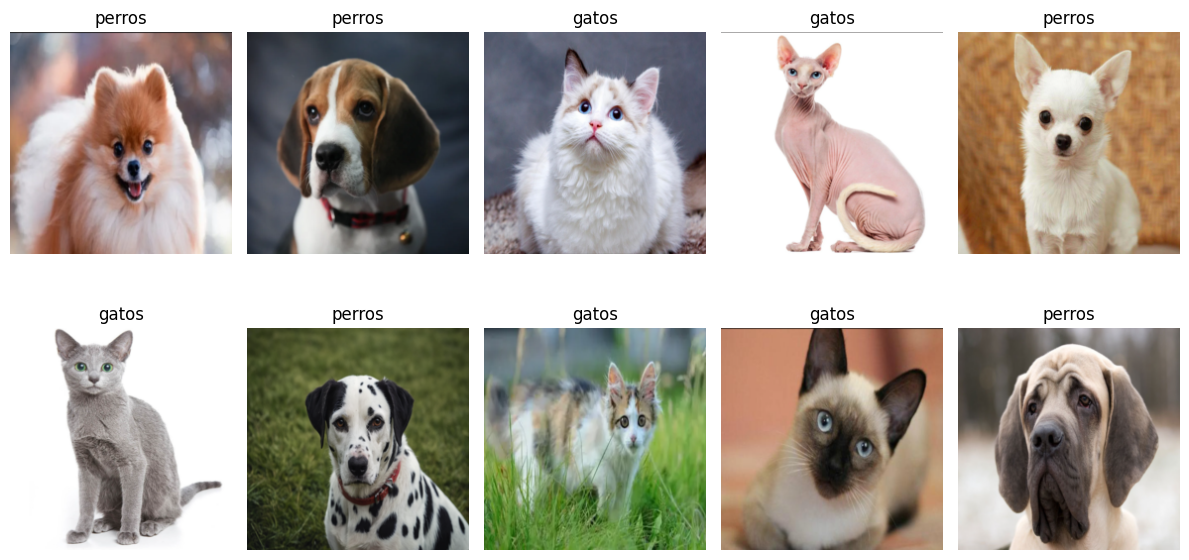

In [14]:
# Function to display a batch of images
import matplotlib.pyplot as plt
import torchvision
def show_batch(loader, classes):
    images, labels = next(iter(loader))
    plt.figure(figsize=(12, 12))
    for i in range (len(images)):
        plt.subplot(4,5, i +1)
        plt.imshow(images[i].permute(1,2,0))
        plt.title(classes[labels[i]])
        plt.axis("off")
    plt.tight_layout()
    plt.show
# Show a batch of images
show_batch(data_loader, custom_data.classes)